In [1]:
import sys

#!pip install XXX --target ./my_custom_packages
sys.path.append('./my_custom_packages')
#import dask.dataframe as dd
#import matplotlib.pyplot as plt
import polars as pl
import time
#import GEOparse
#pl.Config.set_tbl_rows(20)



from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression

#from sklearn.feature_selection import mutual_info_classif
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectFdr, chi2, SelectKBest, SelectFpr, SelectFromModel
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import xgboost as xgb
import optuna
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

import umap


#from tempfile import mkdtemp
#from shutil import rmtree

from sklearn.svm import SVC
import warnings


from sklearn.utils import resample

/opt/jupyterhub-kernels/python312-bio/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PLINK_pca = pd.read_csv("ancestry_pca_plink_data.eigenvec", sep='\s+')
PLINK_pca = PLINK_pca.set_index("IID")
PLINK_pca = PLINK_pca.drop(columns=["#FID"])
PLINK_pca.head()

PLINK_counts = pd.read_csv("matrix_plink_data.raw", sep='\s+')
PLINK_counts = PLINK_counts.set_index('IID')

PLINK_counts = PLINK_counts.drop(columns=['FID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE'])
PLINK_counts.head()

counts_pcs = pd.concat([PLINK_counts, PLINK_pca], axis=1)

# Fill na with most frequent
counts_pcs = counts_pcs.fillna(counts_pcs.median())

counts_pcs.head()



,exm2268640_T,exm44_T,exm55_A,exm192_A,exm2253575_T,exm269_T,exm340_A,exm348_T,exm2264981_A,exm596_A,...,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
IID,,,,,,,,,,,,,,,,,,,,,
1900017,1,0,0,0,0,0,1,0,0,1,...,0.010882,-0.000898,0.008654,-0.004023,-0.000307,-0.002934,0.000773,0.001938,-0.000525,-0.001392
1900029,0,0,0,0,2,0,0,0,2,0,...,-0.017780,-0.002253,-0.013930,0.009291,-0.002188,0.007665,-0.013333,-0.015020,-0.006088,0.016345
1900030,0,0,0,0,0,0,0,0,1,1,...,-0.020871,-0.000086,-0.023377,0.000779,-0.003699,0.003174,0.005266,-0.005349,-0.007326,-0.002667
1900031,0,0,0,0,0,0,0,0,1,0,...,-0.006691,0.000883,0.019278,0.006899,0.008913,0.003361,-0.000787,0.002744,0.004020,0.009813
1900040,0,0,0,0,0,0,1,0,0,0,...,0.012157,-0.000819,0.021606,-0.003193,0.004826,0.004648,0.003146,0.004526,-0.009148,0.010148


In [5]:
annot_data = pd.read_parquet("annot_data_processed.parquet")


mdf = counts_pcs.merge(annot_data, left_index =True, right_on = "Sample")

# Filtering out ex-smokers
mdf = mdf[mdf["Status"] != "Ex-smoker"]
mdf["Gender"] = (mdf["Gender"] == "Male").astype("int8")



y = mdf["Status"] == "Smoker"
# Dropping sample and status columns
mdf_counts = mdf.drop(columns=["Sample", "Status"])

display(mdf_counts.head())


,exm2268640_T,exm44_T,exm55_A,exm192_A,exm2253575_T,exm269_T,exm340_A,exm348_T,exm2264981_A,exm596_A,...,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Age,Gender
140,1,0,0,0,0,0,1,0,0,1,...,0.008654,-0.004023,-0.000307,-0.002934,0.000773,0.001938,-0.000525,-0.001392,35,1
141,0,0,0,0,2,0,0,0,2,0,...,-0.013930,0.009291,-0.002188,0.007665,-0.013333,-0.015020,-0.006088,0.016345,54,1
142,0,0,0,0,0,0,0,0,1,1,...,-0.023377,0.000779,-0.003699,0.003174,0.005266,-0.005349,-0.007326,-0.002667,39,1
143,0,0,0,0,0,0,0,0,1,0,...,0.019278,0.006899,0.008913,0.003361,-0.000787,0.002744,0.004020,0.009813,43,1
144,0,0,0,0,0,0,1,0,0,0,...,0.021606,-0.003193,0.004826,0.004648,0.003146,0.004526,-0.009148,0.010148,59,0


In [6]:
x_train, x_test, y_train, y_test = train_test_split(mdf_counts, y, test_size = 0.2, stratify = y, random_state = 4)

x_train = x_train.copy()
x_test = x_test.copy()


# Initializing a min max scaler
scaler = MinMaxScaler()
# Fitting and transforming the train age
age_train_scaled = scaler.fit_transform(x_train[["Age"]])
# Transforming the test age
age_test_scaled = scaler.transform(x_test[["Age"]])

# Replacing age with scaled age in train
x_train["AgeScaled"] = age_train_scaled
x_train = x_train.drop(columns=["Age"])

# Replacing age with scaled age in test
x_test["AgeScaled"] = age_test_scaled
x_test = x_test.drop(columns=["Age"])



pc_columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']

scaler = StandardScaler()
pcs_train_scaled = scaler.fit_transform(x_train[pc_columns])
pcs_test_scaled = scaler.transform(x_test[pc_columns])

x_train[pc_columns] = pcs_train_scaled
x_test[pc_columns] = pcs_test_scaled



Accuracy score: 0.54
Confusion matrix: 
[[221 127]
 [187 144]]
Classification Report: 
              precision    recall  f1-score   support

       False       0.54      0.64      0.58       348
        True       0.53      0.44      0.48       331

    accuracy                           0.54       679
   macro avg       0.54      0.54      0.53       679
weighted avg       0.54      0.54      0.53       679

ROC AUC Score: 0.56
fpr:  0.49, tpr: 0.59


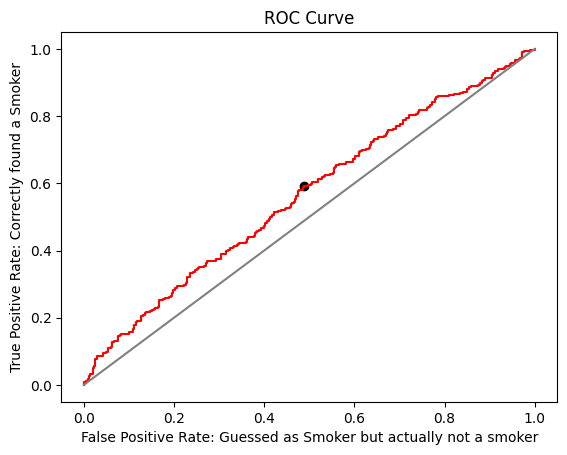

In [27]:
# Establishing Baseline using pcs, age, gender

baseline_features = [
    'AgeScaled', 'Gender', 
    'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 
    'PC6', 'PC7', 'PC8', 'PC9', 'PC10'
]

# Initializing logistic regression
lr = LogisticRegression()

x_train_baseline = x_train[baseline_features]
x_test_baseline = x_test[baseline_features]

# Fitting the model
lr.fit(x_train_baseline, y_train)

# Predicting classes
y_predict = lr.predict(x_test_baseline)
# Predicting probabilities
y_proba = lr.predict_proba(x_test_baseline)

print(f"Accuracy score: {accuracy_score(y_test, y_predict):.2f}")
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_predict))
print("Classification Report: ")
print(classification_report(y_test, y_predict))


# Calculating the ROC AUC score
lr_auc_score = roc_auc_score(y_test, y_proba[:, 1])
print(f"ROC AUC Score: {lr_auc_score:.2f}")


# Calculating ROC curve metrics
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, y_proba[:, 1])



# Plotting the LR model ROC curve
plt.plot(lr_fpr, lr_tpr, color="red", label="LR model")


# Plotting the random guess line
plt.plot([0, 1], [0, 1], color="gray", label="Random guess")
# Setting the x axis label
plt.xlabel("False Positive Rate: Guessed as Smoker but actually not a smoker")
# Setting the y axis label
plt.ylabel("True Positive Rate: Correctly found a Smoker")
# Setting the plot title
plt.title("ROC Curve")

# Calculating Youden's J-statistic

# Subtracting false positive rate from true positive rate
J2 = lr_tpr - lr_fpr
# Finding the maximum J index
i = np.argmax(J2)
# Getting the efficient threshold
lr_efficient_threshold = lr_thresholds[i]

# Plotting the best tradeoff point
plt.scatter(lr_fpr[i], lr_tpr[i], marker="o", color = "black", label=f"best tradeoff: {lr_efficient_threshold:.2f}")

# Printing the false and true positive rates
print(f"fpr: {lr_fpr[i]: .2f}, tpr: {lr_tpr[i]:.2f}")


# Showing the plot
plt.show()

In [38]:
# LogisticRegression by lasso through OPTUNA optimiser

time1 = time.time()

# Sever core management
OPTUNA_TRIALS_AT_ONCE = 14
LR_CORES_PER_TRIAL = 8

warnings.filterwarnings("ignore", message="No features were selected")

cv_strategy = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 4)


def objective(trial):

    selector_c = trial.suggest_float('selector_c', 0.01, 100.0, log=True)
    
    lr_c = trial.suggest_float('lr_c', 1e-5, 1000.0, log=True)
    lr_penalty = trial.suggest_categorical('lr_penalty', ['l1', 'l2'])
    
    
    lasso_selector = SelectFromModel(
        LogisticRegression(
            penalty = 'l1', 
            solver = 'liblinear',
            C = selector_c, 
            max_iter = 5000, 
            random_state = 4
        )
    )
    
    lr_model = LogisticRegression(
        penalty = lr_penalty,
        solver = 'saga',
        C = lr_c,
        max_iter = 5000,
        tol = 0.005,
        n_jobs = LR_CORES_PER_TRIAL,
        random_state = 4
    )
    
    # PIPELINE
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso_selection', lasso_selector),
        ('classifier', lr_model)
    ])
    
    try:
        # Keeping cv n_jobs=1 because Optuna is already parallelizing the trials themselves.
        scores = cross_val_score(
            pipeline, 
            x_train, 
            y_train, 
            cv = cv_strategy, #
            scoring = "roc_auc",
            n_jobs = 1 
        )

        return scores.mean()

    except ValueError:
        # If the pipeline crashes because 0 features were selected, 
        return 0.50


# Create the study object
study = optuna.create_study(direction="maximize")

# Run  300 trials
study.optimize(objective, n_trials = 300, n_jobs = OPTUNA_TRIALS_AT_ONCE)

print(f"Best AUC Score: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

print(f"Took: {time.time() - time1:.2f} seconds")

[I 2026-06-17 22:56:24,817] A new study created in memory with name: no-name-dd90c640-b25d-4b98-ae12-4d1fa4b5fd5b
[I 2026-06-17 23:04:43,309] Trial 5 finished with value: 0.5 and parameters: {'selector_c': 0.03226503713288326, 'lr_c': 0.0024143244867323543, 'lr_penalty': 'l1'}. Best is trial 5 with value: 0.5.
[I 2026-06-17 23:04:50,427] Trial 6 finished with value: 0.5503879712361348 and parameters: {'selector_c': 0.056304240904877394, 'lr_c': 27.037738631914788, 'lr_penalty': 'l2'}. Best is trial 6 with value: 0.5503879712361348.
[I 2026-06-17 23:04:51,602] Trial 2 finished with value: 0.5772948906766588 and parameters: {'selector_c': 0.7824233805471625, 'lr_c': 0.00023000197314076252, 'lr_penalty': 'l2'}. Best is trial 2 with value: 0.5772948906766588.
[I 2026-06-17 23:04:58,273] Trial 12 finished with value: 0.5802089142083463 and parameters: {'selector_c': 0.0866066092856902, 'lr_c': 0.010064041951447118, 'lr_penalty': 'l1'}. Best is trial 12 with value: 0.5802089142083463.
[I 202

[I 2026-06-17 23:14:07,539] Trial 24 finished with value: 0.5761344540225647 and parameters: {'selector_c': 27.14072537754985, 'lr_c': 0.0630692139947357, 'lr_penalty': 'l1'}. Best is trial 31 with value: 0.5901639624732204.
[I 2026-06-17 23:14:08,433] Trial 37 finished with value: 0.5816089520727916 and parameters: {'selector_c': 2.1798277397234544, 'lr_c': 0.00022231799086927436, 'lr_penalty': 'l2'}. Best is trial 31 with value: 0.5901639624732204.
[I 2026-06-17 23:14:12,342] Trial 38 finished with value: 0.5810521213924281 and parameters: {'selector_c': 3.749109694367027, 'lr_c': 0.00020079394476675734, 'lr_penalty': 'l2'}. Best is trial 31 with value: 0.5901639624732204.
[I 2026-06-17 23:15:27,108] Trial 39 finished with value: 0.582111647660682 and parameters: {'selector_c': 2.6522082990309386, 'lr_c': 0.0003232970793323756, 'lr_penalty': 'l2'}. Best is trial 31 with value: 0.5901639624732204.
[I 2026-06-17 23:17:08,077] Trial 40 finished with value: 0.5742016134187661 and paramet

[I 2026-06-17 23:27:00,888] Trial 70 finished with value: 0.5795959630108626 and parameters: {'selector_c': 14.716398106808828, 'lr_c': 0.0006674301264312509, 'lr_penalty': 'l2'}. Best is trial 31 with value: 0.5901639624732204.
[I 2026-06-17 23:27:22,739] Trial 71 finished with value: 0.5794816812305453 and parameters: {'selector_c': 15.194382360804825, 'lr_c': 0.0012286069237914634, 'lr_penalty': 'l2'}. Best is trial 31 with value: 0.5901639624732204.
[I 2026-06-17 23:27:29,544] Trial 72 finished with value: 0.5797903604662408 and parameters: {'selector_c': 14.466868302754538, 'lr_c': 0.0007262854061780209, 'lr_penalty': 'l2'}. Best is trial 31 with value: 0.5901639624732204.
[I 2026-06-17 23:27:43,607] Trial 73 finished with value: 0.5745968522516232 and parameters: {'selector_c': 13.173412103317485, 'lr_c': 0.0007811501054884261, 'lr_penalty': 'l2'}. Best is trial 31 with value: 0.5901639624732204.
[I 2026-06-17 23:27:44,445] Trial 75 finished with value: 0.5838676461428259 and par

[I 2026-06-17 23:36:48,848] Trial 104 finished with value: 0.5848781555753346 and parameters: {'selector_c': 37.38332398384042, 'lr_c': 3.455281365401351e-05, 'lr_penalty': 'l2'}. Best is trial 94 with value: 0.5904914018204439.
[I 2026-06-17 23:37:03,289] Trial 107 finished with value: 0.5783059902044188 and parameters: {'selector_c': 31.393489103653593, 'lr_c': 3.744011870557483e-05, 'lr_penalty': 'l2'}. Best is trial 94 with value: 0.5904914018204439.
[I 2026-06-17 23:37:03,371] Trial 103 finished with value: 0.5869215120043405 and parameters: {'selector_c': 99.7163767847927, 'lr_c': 3.592791582678377e-05, 'lr_penalty': 'l2'}. Best is trial 94 with value: 0.5904914018204439.
[I 2026-06-17 23:38:07,857] Trial 108 finished with value: 0.5849667046950272 and parameters: {'selector_c': 32.89870283003831, 'lr_c': 3.282663350805883e-05, 'lr_penalty': 'l2'}. Best is trial 94 with value: 0.5904914018204439.
[I 2026-06-17 23:38:59,706] Trial 110 finished with value: 0.5867115999613159 and pa

[I 2026-06-17 23:48:40,040] Trial 140 finished with value: 0.5855841020963134 and parameters: {'selector_c': 51.50742026907691, 'lr_c': 1.1803889723108023e-05, 'lr_penalty': 'l2'}. Best is trial 128 with value: 0.5911152759269003.
[I 2026-06-17 23:48:46,383] Trial 137 finished with value: 0.5837893089492863 and parameters: {'selector_c': 54.549340710525286, 'lr_c': 6.0265410959889355e-05, 'lr_penalty': 'l2'}. Best is trial 128 with value: 0.5911152759269003.
[I 2026-06-17 23:49:20,844] Trial 142 finished with value: 0.5891031023438256 and parameters: {'selector_c': 44.53812556983664, 'lr_c': 1.5131094996036061e-05, 'lr_penalty': 'l2'}. Best is trial 128 with value: 0.5911152759269003.
[I 2026-06-17 23:49:26,834] Trial 141 finished with value: 0.5808552754515457 and parameters: {'selector_c': 56.62752393256845, 'lr_c': 1.108457916468013e-05, 'lr_penalty': 'l2'}. Best is trial 128 with value: 0.5911152759269003.
[I 2026-06-17 23:50:22,337] Trial 143 finished with value: 0.584648331915465

[I 2026-06-18 00:00:07,722] Trial 174 finished with value: 0.5825497810910533 and parameters: {'selector_c': 28.839111936217087, 'lr_c': 5.2066857058468906e-05, 'lr_penalty': 'l2'}. Best is trial 128 with value: 0.5911152759269003.
[I 2026-06-18 00:00:14,459] Trial 173 finished with value: 0.5882999745111634 and parameters: {'selector_c': 30.573868664742978, 'lr_c': 0.00010208770363057128, 'lr_penalty': 'l2'}. Best is trial 128 with value: 0.5911152759269003.
[I 2026-06-18 00:00:22,729] Trial 172 finished with value: 0.5713826771801971 and parameters: {'selector_c': 0.98538776845762, 'lr_c': 94.20703950017138, 'lr_penalty': 'l2'}. Best is trial 128 with value: 0.5911152759269003.
[I 2026-06-18 00:00:38,964] Trial 176 finished with value: 0.5836660446079227 and parameters: {'selector_c': 67.83909583995143, 'lr_c': 5.087716058670249e-05, 'lr_penalty': 'l2'}. Best is trial 128 with value: 0.5911152759269003.
[I 2026-06-18 00:00:59,225] Trial 177 finished with value: 0.585302600025243 and 

[I 2026-06-18 00:11:04,142] Trial 209 finished with value: 0.5865411320977395 and parameters: {'selector_c': 86.72665388898339, 'lr_c': 1.527491576041947e-05, 'lr_penalty': 'l2'}. Best is trial 199 with value: 0.5920402031075072.
[I 2026-06-18 00:11:32,673] Trial 212 finished with value: 0.5877635062148504 and parameters: {'selector_c': 88.01653679062022, 'lr_c': 1.5338393023719568e-05, 'lr_penalty': 'l2'}. Best is trial 199 with value: 0.5920402031075072.
[I 2026-06-18 00:11:39,626] Trial 211 finished with value: 0.5875446177576052 and parameters: {'selector_c': 86.2695582808744, 'lr_c': 1.547729788034783e-05, 'lr_penalty': 'l2'}. Best is trial 199 with value: 0.5920402031075072.
[I 2026-06-18 00:12:22,875] Trial 206 finished with value: 0.5814393345200805 and parameters: {'selector_c': 47.55888491132798, 'lr_c': 5.705159675550614, 'lr_penalty': 'l2'}. Best is trial 199 with value: 0.5920402031075072.
[I 2026-06-18 00:12:59,503] Trial 217 finished with value: 0.5844328672400426 and pa

[I 2026-06-18 00:22:27,415] Trial 241 finished with value: 0.58365330018965 and parameters: {'selector_c': 58.453686294435045, 'lr_c': 4.132967394292422e-05, 'lr_penalty': 'l2'}. Best is trial 199 with value: 0.5920402031075072.
[I 2026-06-18 00:22:56,420] Trial 243 finished with value: 0.5882997778127464 and parameters: {'selector_c': 58.41668577780769, 'lr_c': 4.0593798456700845e-05, 'lr_penalty': 'l2'}. Best is trial 199 with value: 0.5920402031075072.
[I 2026-06-18 00:23:02,608] Trial 244 finished with value: 0.5865995064508885 and parameters: {'selector_c': 58.36798070503794, 'lr_c': 2.3261775735297707e-05, 'lr_penalty': 'l2'}. Best is trial 199 with value: 0.5920402031075072.
[I 2026-06-18 00:23:19,150] Trial 245 finished with value: 0.5846009009607078 and parameters: {'selector_c': 75.4265421721348, 'lr_c': 2.1905260087426203e-05, 'lr_penalty': 'l2'}. Best is trial 199 with value: 0.5920402031075072.
[I 2026-06-18 00:24:16,175] Trial 247 finished with value: 0.5923963173958441 a

[I 2026-06-18 00:34:04,546] Trial 276 finished with value: 0.5815658710215696 and parameters: {'selector_c': 38.79899517463236, 'lr_c': 1.410723291508733e-05, 'lr_penalty': 'l2'}. Best is trial 251 with value: 0.5927329892750188.
[I 2026-06-18 00:34:20,531] Trial 278 finished with value: 0.5905842209349405 and parameters: {'selector_c': 64.04866264051847, 'lr_c': 1.0423342760913898e-05, 'lr_penalty': 'l2'}. Best is trial 251 with value: 0.5927329892750188.
[I 2026-06-18 00:34:28,427] Trial 277 finished with value: 0.5838429604914838 and parameters: {'selector_c': 61.80330995223468, 'lr_c': 1.3426145206751032e-05, 'lr_penalty': 'l2'}. Best is trial 251 with value: 0.5927329892750188.
[I 2026-06-18 00:34:42,797] Trial 279 finished with value: 0.5882174636230865 and parameters: {'selector_c': 63.4169955516208, 'lr_c': 1.0517598047220127e-05, 'lr_penalty': 'l2'}. Best is trial 251 with value: 0.5927329892750188.
[I 2026-06-18 00:34:55,660] Trial 280 finished with value: 0.5857796223718224 

Best AUC Score: 0.5927
Best Parameters:
  selector_c: 74.55921027239522
  lr_c: 2.1696702138036444e-05
  lr_penalty: l2
Took: 6212.13 seconds


In [1]:
"""
Lasso feature selection thresholds
Total features: 45221
C = 1e-05    | Features: 0
C = 0.0001   | Features: 0
C = 0.001    | Features: 0
C = 0.01     | Features: 2
C = 0.1      | Features: 1442
C = 1.0      | Features: 2344
C = 10.0     | Features: 4517
"""

'\nLasso feature selection thresholds\nTotal features: 45221\nC = 1e-05    | Features: 0\nC = 0.0001   | Features: 0\nC = 0.001    | Features: 0\nC = 0.01     | Features: 2\nC = 0.1      | Features: 1442\nC = 1.0      | Features: 2344\nC = 10.0     | Features: 4517\n'

In [13]:
lasso_selector = SelectFromModel(
    LogisticRegression(
        penalty = 'l1', 
        solver = 'liblinear',
        C = 74.5592, 
        max_iter = 10000, 
        random_state = 4
    )
)

lr_b = LogisticRegression(
    penalty = 'l2',
    solver = 'saga',
    C = 2.1696e-05,
    max_iter = 10000,
    tol = 0.001,
    n_jobs = -1,
    random_state = 4
)

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso_selection', lasso_selector),
    ('classifier', lr_b)
])

final_pipeline.fit(x_train, y_train)

y_predict_b = final_pipeline.predict(x_test)
y_proba_b = final_pipeline.predict_proba(x_test)

print(f"Accuracy score: {accuracy_score(y_test, y_predict_b):.2f}")
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_predict_b))
print("Classification Report: ")
print(classification_report(y_test, y_predict_b))

lr_auc_score_b = roc_auc_score(y_test, y_proba_b[:, 1])
print(f"ROC AUC Score: {lr_auc_score_b:.2f}")

Accuracy score: 0.53
Confusion matrix: 
[[196 152]
 [165 166]]
Classification Report: 
              precision    recall  f1-score   support

       False       0.54      0.56      0.55       348
        True       0.52      0.50      0.51       331

    accuracy                           0.53       679
   macro avg       0.53      0.53      0.53       679
weighted avg       0.53      0.53      0.53       679

ROC AUC Score: 0.56


In [18]:
# Initializing stratified k fold
cv_strategy = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 4)

# Generating lambda values to try
lambdas_to_try = np.logspace(-4, 2, 100)

# Initializing logistic regression CV
logistic_lasso = LogisticRegression(
    # Setting the cross validation strategy
    # Setting the C parameters
    C = 74.5592,
    # Setting the maximum iterations
    max_iter = 10000,
    # Setting the random state
    random_state = 4,
    # Setting the penalty type
    penalty = "l1", #absolute value
    # Setting the solver
    solver = "liblinear", #Coordinate descent, one variable at a time
)


# Fitting the lasso model
logistic_lasso.fit(x_train, y_train)


# Finding significant features
significant_features = logistic_lasso.coef_[0] != 0

# Filtering train data with significant features
x_train_significant = x_train.loc[:, significant_features]
# Filtering test data with significant features
x_test_significant = x_test.loc[:, significant_features]

# Printing the number of significant features
print(x_train_significant.shape[1])

11011


In [25]:
# Predicting probabilities for the lasso model

lr = LogisticRegression(max_iter = 10000)

lr.fit(x_train_significant, y_train)

y_proba_lasso = lr.predict_proba(x_test_significant)
y_predict_lasso = lr.predict(x_test_significant)


# Calculating the roc auc score
score_lasso = roc_auc_score(y_test, y_proba_lasso[:, 1])


print(f"Accuracy score: {accuracy_score(y_test, y_predict_lasso):.2f}")
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_predict_lasso))
print("Classification Report: ")
print(classification_report(y_test, y_predict_lasso))

auc_score = roc_auc_score(y_test, y_proba_lasso[:, 1])
print(f"ROC AUC Score: {auc_score:.2f}")

Accuracy score: 0.52
Confusion matrix: 
[[190 158]
 [168 163]]
Classification Report: 
              precision    recall  f1-score   support

       False       0.53      0.55      0.54       348
        True       0.51      0.49      0.50       331

    accuracy                           0.52       679
   macro avg       0.52      0.52      0.52       679
weighted avg       0.52      0.52      0.52       679

ROC AUC Score: 0.53


In [29]:
s = MinMaxScaler()

x_tr = s.fit_transform(x_train)
x_te = s.transform(x_test) 

select = SelectFpr(score_func=chi2, alpha=0.01)


x_train_significant = select.fit_transform(x_tr, y_train)
x_test_significant = select.transform(x_te)


print(x_train_significant.shape[1])


29


In [30]:
# Predicting probabilities for the lasso model

lr = LogisticRegression(max_iter = 10000)

lr.fit(x_train_significant, y_train)

y_proba_lasso = lr.predict_proba(x_test_significant)
y_predict_lasso = lr.predict(x_test_significant)


# Calculating the roc auc score
score_lasso = roc_auc_score(y_test, y_proba_lasso[:, 1])


print(f"Accuracy score: {accuracy_score(y_test, y_predict_lasso):.2f}")
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_predict_lasso))
print("Classification Report: ")
print(classification_report(y_test, y_predict_lasso))

auc_score = roc_auc_score(y_test, y_proba_lasso[:, 1])
print(f"ROC AUC Score: {auc_score:.2f}")

Accuracy score: 0.54
Confusion matrix: 
[[198 150]
 [159 172]]
Classification Report: 
              precision    recall  f1-score   support

       False       0.55      0.57      0.56       348
        True       0.53      0.52      0.53       331

    accuracy                           0.54       679
   macro avg       0.54      0.54      0.54       679
weighted avg       0.54      0.54      0.54       679

ROC AUC Score: 0.55


In [43]:

# Separate your SNPs from your PCs
pc_cols = [col for col in x_train.columns if "PC" in col]
snp_cols = [col for col in x_train.columns if col not in pc_cols]

x_train_snps_raw = x_train[snp_cols]

# FPR strictly on allele counts
select = SelectFpr(score_func=chi2, alpha=0.01)
x_train_significant = select.fit_transform(x_train_snps_raw, y_train)
x_test_significant = select.transform(x_test[snp_cols])
print(f"Features kept without scaling: {x_train_significant.shape[1]}")

Features kept without scaling: 286


In [47]:
print(x_train_significant.shape[1])
genes = select.get_feature_names_out(input_features=x_train[snp_cols].columns)

for gene in genes:
    print(gene)


286
exm2941_T
exm3098_A
exm10780_A
exm14051_T
exm15048_A
exm19473_T
exm26842_T
exm28784_A
exm37420_A
exm46358_T
exm46586_T
exm57130_T
exm57139_T
exm61019_A
exm62367_T
exm73033_A
exm-rs7543130_A
exm78533_T
exm79239_A
exm81447_A
exm-rs484959_T
exm83704_T
exm84167_T
exm-rs2282301_A
exm118680_A
exm2277017_A
exm1748365_A
exm145016_A
exm-rs4844614_T
exm146417_A
exm150788_A
exm179212_T
exm193576_A
exm208737_A
exm-rs7571971_T
exm234238_A
exm253823_T
exm253996_A
exm273546_A
exm289504_A
exm294480_T
exm302284_A
exm302344_A
exm302383_A
exm302436_A
exm320242_A
exm2265599_A
exm335291_T
exm339451_T
exm342005_A
exm348917_A
exm351625_T
exm357881_A
exm368151_T
exm368344_A
exm2269699_T
exm394243_T
exm-rs10938462_T
exm404147_A
exm2261777_T
exm2256803_A
exm418184_T
exm429764_T
exm-rs4234898_A
exm464423_T
exm472227_T
exm480666_A
exm482462_T
exm499583_A
exm511471_A
exm518723_T
exm2270456_A
exm-rs2274089_T
exm521119_A
exm522653_T
exm523141_A
exm-rs3128854_T
exm526329_A
exm-rs2735052_A
exm-rs2743951_A
exm-rs16

In [44]:
lr = LogisticRegression(max_iter = 10000)

lr.fit(x_train_significant, y_train)

y_proba_lasso = lr.predict_proba(x_test_significant)
y_predict_lasso = lr.predict(x_test_significant)


# Calculating the roc auc score
score_lasso = roc_auc_score(y_test, y_proba_lasso[:, 1])


print(f"Accuracy score: {accuracy_score(y_test, y_predict_lasso):.2f}")
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_predict_lasso))
print("Classification Report: ")
print(classification_report(y_test, y_predict_lasso))

auc_score = roc_auc_score(y_test, y_proba_lasso[:, 1])
print(f"ROC AUC Score: {auc_score:.2f}")

Accuracy score: 0.54
Confusion matrix: 
[[201 147]
 [167 164]]
Classification Report: 
              precision    recall  f1-score   support

       False       0.55      0.58      0.56       348
        True       0.53      0.50      0.51       331

    accuracy                           0.54       679
   macro avg       0.54      0.54      0.54       679
weighted avg       0.54      0.54      0.54       679

ROC AUC Score: 0.57


In [35]:
x_train_stability = x_train_snps_raw

n_iterations = 100

# Keep genes that are selected in at least 80% of the random shuffles
stability_threshold = 0.80 

n_features = x_train_stability.shape[1]
selection_counts = np.zeros(n_features)

print(f"Running stability selection for {n_features} features over {n_iterations} iterations")
start_time = time.time()

for i in range(n_iterations):
    # Bootstrap sample random pick 80% of the training data
    x_boot, y_boot = resample(x_train_stability, y_train, 
                              n_samples=int(0.8 * len(x_train_stability)), 
                              random_state=i, 
                              stratify=y_train)
    
    # FPR
    selector = SelectFpr(score_func=chi2, alpha=0.01)
    selector.fit(x_boot, y_boot)
    
    # Add the surviving features to our tally
    selection_counts += selector.get_support().astype(int)
    
    if (i + 1) % 10 == 0:
        print(f"Completed {i + 1} / {n_iterations} iterations")

print(f"Took {time.time() - start_time:.2f}s")


# Calculate the probability that each feature was selected
selection_probs = selection_counts / n_iterations

feature_mask = selection_probs >= stability_threshold

# Get the column names of genes
gene_names = x_train_stability.columns[feature_mask]

x_train_significant = x_train_stability[gene_names].copy()
x_test_significant = x_test[gene_names].copy()


print(f"Total features: {selection_counts}")

Running stability selection for 45211 features over 100 iterations
Completed 20 / 100 iterations
Completed 30 / 100 iterations
Completed 40 / 100 iterations
Completed 50 / 100 iterations
Completed 60 / 100 iterations
Completed 70 / 100 iterations
Completed 80 / 100 iterations
Completed 90 / 100 iterations
Completed 100 / 100 iterations
Took 362.14s


NameError: name 'robust_gene_names' is not defined

In [39]:
x_train_significant = x_train_stability[gene_names].copy()
x_test_significant = x_test[gene_names].copy()


print(f"Total features: {len(gene_names)}")


Total features: 13


In [40]:
lr = LogisticRegression(max_iter = 10000)

lr.fit(x_train_significant, y_train)

y_proba_lasso = lr.predict_proba(x_test_significant)
y_predict_lasso = lr.predict(x_test_significant)


# Calculating the roc auc score
score_lasso = roc_auc_score(y_test, y_proba_lasso[:, 1])


print(f"Accuracy score: {accuracy_score(y_test, y_predict_lasso):.2f}")
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_predict_lasso))
print("Classification Report: ")
print(classification_report(y_test, y_predict_lasso))

auc_score = roc_auc_score(y_test, y_proba_lasso[:, 1])
print(f"ROC AUC Score: {auc_score:.2f}")

Accuracy score: 0.55
Confusion matrix: 
[[223 125]
 [179 152]]
Classification Report: 
              precision    recall  f1-score   support

       False       0.55      0.64      0.59       348
        True       0.55      0.46      0.50       331

    accuracy                           0.55       679
   macro avg       0.55      0.55      0.55       679
weighted avg       0.55      0.55      0.55       679

ROC AUC Score: 0.55


In [54]:
humanexom_data = pl.read_csv("GPL18545_humanexome-12v1-1_a.csv", skip_rows = 7, schema_overrides = {"Chr": pl.String})

# 1. Paste your original 189 features here (just the first 5-10 for testing is fine if you don't want to paste all 189)
original_189 = [
    "exm-rs1055388-131_B_R_1990478034",
"exm-rs11605924-131_B_R_1990478586",
"exm-rs12793173-131_T_R_1990488308",
"exm-rs1633017-131_B_R_1990479888",
"exm-rs1633036-131_B_R_1990479892",
"exm-rs16982520-131_T_F_1990489099",
"exm-rs1751492-131_B_F_1990480221",
"exm-rs2032672-131_B_R_1990480579",
"exm-rs2032673-131_B_F_2058870696",
"exm-rs2300478-131_T_R_1990490227",
"exm-rs2357013-131_B_F_1990481237",
"exm-rs2517713-131_B_R_1990481493",
"exm-rs2517723-131_T_F_1990490523",
"exm-rs2523393-131_T_R_1990490536",
"exm-rs2523987-131_T_R_1990490600",
"exm-rs2690775-131_B_R_1990481734",
"exm-rs2857105-131_B_R_1990482043",
"exm-rs2895811-131_T_R_1990491146",
"exm-rs3093978-131_B_F_1990482224",
"exm-rs3093992-131_B_F_1990482226",
"exm-rs3130055-131_B_F_1990482441",
"exm-rs3131628-131_B_R_1990482545",
"exm-rs3135031-132_T_R_1990486720",
"exm-rs3763365-131_T_R_1990491821",
"exm-rs4795519-131_B_R_1990483578",
"exm-rs6687758-131_T_F_1990493250",
"exm-rs7009183-131_B_R_1990484711",
"exm-rs7236632-131_T_F_1990493768",
"exm-rs7851008-131_B_R_1990485405",
"exm-rs7874142-131_T_F_1990494312",
"exm-rs889312-131_B_R_1990485746",
"exm-rs9261136-131_B_F_1990485815",
"exm-rs9354308-131_T_F_1990494827",
"exm-rs9386463-131_T_F_1990494865",
"exm-rs981782-131_B_F_1990486349",
"exm1003221-0_B_F_1922459857",
"exm1005604-0_B_R_2060120989",
"exm1046037-0_B_R_1922457814",
"exm1049090-0_B_R_1922468248",
"exm1052631-0_T_R_1922512764",
"exm1058585-0_T_R_1921795558",
"exm1070267-0_T_R_1921791766",
"exm1099805-0_B_F_2060125381",
"exm1101703-0_T_R_1922773380",
"exm1111523-0_T_R_1922760514",
"exm1166947-0_B_F_2060134496",
"exm1170469-0_B_R_1922897766",
"exm1227291-0_B_R_1921669424",
"exm1256052-0_B_R_1921762006",
"exm1261720-0_T_R_1921658892",
"exm1299012-0_T_F_1918631075",
"exm1301695-0_B_R_1918710132",
"exm1323086-0_T_F_1918701195",
"exm1337556-0_T_R_2060140163",
"exm1340665-0_B_F_1918703873",
"exm1364554-0_T_F_1918610443",
"exm1371824-0_B_F_1921617749",
"exm1379120-0_T_F_1921625489",
"exm1381964-0_B_F_1921617517",
"exm1392158-0_B_F_1921597787",
"exm1413325-0_T_F_1923228411",
"exm1421227-0_T_R_1920949617",
"exm1421650-0_T_F_1923324725",
"exm1422931-0_B_R_1923170364",
"exm1426256-0_T_F_1920924992",
"exm1460682-0_B_F_1920901640",
"exm148329-0_T_F_1921382899",
"exm1500432-0_T_R_1923265920",
"exm1551360-0_B_R_2060147290",
"exm1619299-0_B_F_1919063263",
"exm1624867-0_B_R_1922046652",
"exm1634496-0_T_R_1922055856",
"exm1634727-0_T_F_1922083711",
"exm1636370-0_T_F_1922073495",
"exm1636560-0_B_R_1922068464",
"exm1636637-0_B_R_1922016644",
"exm1637817-0_T_R_1922060748",
"exm1638188-0_B_R_1922072166",
"exm1645729-0_T_R_1922091922",
"exm1645741-0_T_F_1922044815",
"exm1650684-0_B_F_1922079535",
"exm1658728-0_T_R_1922061316",
"exm1660826-0_T_R_1922035096",
"exm173637-0_B_F_1918843435",
"exm195194-0_T_F_1918949299",
"exm2216268-0_B_R_1955482116",
"exm2216443-0_B_R_1955482529",
"exm2250350-0_T_R_1975250187",
"exm2253615-0_T_R_1975267087",
"exm2253987-0_B_F_1975267632",
"exm2256803-0_T_R_1975248357",
"exm2262124-0_B_R_1975244784",
"exm2262311-0_T_R_1975241234",
"exm2262847-0_B_R_1975245048",
"exm2263220-0_T_R_1975252237",
"exm2263233-0_T_R_1975241554",
"exm2263298-0_T_R_1975249931",
"exm2264714-0_B_R_1984852982",
"exm2264785-0_T_F_1984849652",
"exm2265713-0_T_F_1984856541",
"exm2266552-0_B_R_1984841924",
"exm2267299-0_B_R_1984840359",
"exm2267448-0_B_R_1984852402",
"exm2267928-0_B_R_1984847561",
"exm2267993-0_B_R_1984842184",
"exm2268469-0_B_R_1984849557",
"exm2268914-0_B_F_2060143912",
"exm2273088-0_T_R_1984849471",
"exm2273203-0_B_F_1984849340",
"exm236098-0_T_R_1918982506",
"exm240449-0_T_R_1918802524",
"exm243224-0_B_R_1919004432",
"exm252592-0_T_R_1919005690",
"exm256070-0_B_R_1919007682",
"exm26660-0_T_R_1919163146",
"exm307405-0_T_R_1922161404",
"exm308431-0_B_F_1922175047",
"exm317474-0_B_F_1922239353",
"exm32098-0_B_F_1921427907",
"exm325740-0_B_F_1922162927",
"exm338822-0_B_R_1922192552",
"exm350859-0_B_F_1922272433",
"exm371670-0_B_R_1922250324",
"exm381774-0_T_R_1923133868",
"exm381920-0_B_R_1923142596",
"exm404316-0_T_R_1923140264",
"exm407752-0_T_F_1923083325",
"exm408664-0_B_F_1923106203",
"exm423996-0_T_F_1923135695",
"exm433190-0_T_R_1923125182",
"exm447675-0_T_F_2060137902",
"exm449634-0_B_R_1921129429",
"exm460478-0_T_R_1921151081",
"exm517555-0_B_F_1921876355",
"exm518602-0_B_F_1921918305",
"exm530864-0_B_R_1921937786",
"exm540533-0_T_F_1921935363",
"exm554460-0_B_F_1921911677",
"exm566503-0_B_F_1921959011",
"exm579029-0_B_R_1921907984",
"exm579280-0_B_F_1921992619",
"exm583968-0_T_F_1921882837",
"exm588109-0_T_R_1922000210",
"exm607285-0_T_R_1918572534",
"exm609218-0_B_F_1918575531",
"exm620684-0_B_R_1918449516",
"exm622435-0_T_F_1918447611",
"exm62699-0_T_F_1921353081",
"exm642104-0_T_R_1918485926",
"exm655857-0_T_R_1918577498",
"exm657813-0_T_F_1918512339",
"exm665978-0_B_R_1918485806",
"exm699888-0_T_R_1922907522",
"exm708704-0_T_F_1922910357",
"exm709121-0_B_F_1922913749",
"exm717740-0_B_R_2060145534",
"exm735583-0_B_R_1922406336",
"exm759751-0_T_R_1922412944",
"exm761004-0_T_R_2058863075",
"exm76266-0_B_R_1919163770",
"exm765802-0_B_R_1922401848",
"exm797536-0_B_F_1922419497",
"exm823897-0_T_F_1920985570",
"exm83693-0_B_R_1921486202",
"exm840844-0_B_R_1920955709",
"exm859622-0_B_R_1921071437",
"exm879831-0_T_F_1918265281",
"exm88230-0_B_R_1921541946",
"exm882819-0_B_F_1918373195",
"exm882856-0_T_R_1918354212",
"exm884003-0_B_R_1918194914",
"exm887174-0_B_F_1918236902",
"exm888986-0_T_R_1918371156",
"exm89244-0_T_R_1921505794",
"exm90874-0_T_F_1921558619",
"exm920376-0_T_R_1918256312",
"exm926170-0_T_F_1918283763",
"exm929458-0_T_F_1918319471",
"exm944011-0_B_R_1918207660",
"exm945167-0_B_F_1918385193",
"exm948002-0_B_F_1918368517",
"exm950535-0_T_R_1918275356",
"exm964530-0_B_R_1918291731",
"exm973902-0_T_F_1922460259",
"exm976715-0_T_R_1922430612",
"exm983981-0_B_R_1922590222",
"exm986830-0_B_R_1922435978",
"exm990481-0_B_F_1922458989"

]


manifest = humanexom_data.to_pandas() if hasattr(humanexom_data, 'to_pandas') else humanexom_data

golden_manifest = manifest[manifest['IlmnID'].isin(original_189)]

vcf_ids = golden_manifest['Name'].tolist()

plink_columns = x_train_snps_raw.columns.tolist()

found_in_plink = []
missing_from_plink = []

for base_id in vcf_ids:
    match = [col for col in plink_columns if col.startswith(base_id + "_")]
    if match:
        found_in_plink.append((base_id, match[0]))
    else:
        missing_from_plink.append(base_id)

print(f"{len(vcf_ids)} good genes checked.")
print(f"{len(found_in_plink)} survived PLINK's MAF filter and are IN the 45k dataset.")
print(f"{len(missing_from_plink)} were deleted.")


188 good genes checked.
160 survived PLINK's MAF filter and are IN the 45k dataset.
28 were deleted.


In [55]:
plink_col_name = [c for c in x_train_snps_raw.columns if c.startswith("exm-rs1055388_")][0]
plink_counts = x_train_snps_raw[plink_col_name].value_counts()
print("PLINK counts:")
print(plink_counts)

PLINK counts:
exm-rs1055388_T
2    1851
1     783
0      82
Name: count, dtype: int64
